# 📈 Demand Forecasting — NYC → Dubai

**Business Question:** *"When should a platform push Dubai inventory to NYC users — and how far in advance?"*

### Data Sources
| Source | What It Provides | 
|--------|-----------------|
| Google Trends (pytrends) | Weekly search interest for Dubai travel keywords | 
| Aviation Edge API | Flight routes, schedules, capacity (JFK/EWR → DXB) | 

### Approach
1. Load **Aviation Edge** data → monthly flight capacity (supply proxy)
2. Load **Google Trends** data → search interest (demand signal)
3. Merge into monthly time series
4. Forecast with **Prophet** (holidays + regressors) and **SARIMA** (baseline)
5. Analyze search → demand lag → **push timing recommendations**


In [7]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

from config.settings import (
    AVIATION_EDGE_API_KEY, GOOGLE_CLOUD_API_KEY,
    TRENDS_KEYWORDS, DATA_RAW, DATA_PROCESSED,
    FIGURES_DIR, OUTPUTS,
)
from src.data_collection.google_trends import (
    fetch_google_trends,
    detect_search_spikes, extract_seasonal_patterns,
    save_trends_data
)
from src.data_collection.aviation_edge import (
    save_aviation_data, load_aviation_data,
)
from src.analysis.demand_forecaster import (
    prepare_forecast_data, train_prophet_model, train_sarima_model,
    generate_push_timing, compare_models, analyze_search_demand_lag,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 120

print("Setup complete")

Setup complete


In [8]:
# ═══════════════════════════════════════════════════════════
# 1. DATA INGESTION
# ═══════════════════════════════════════════════════════════

from scripts.generate_seeds import generate_trends, generate_capacity

# ── Google Trends (demand signal) ──
trends_raw = None
if GOOGLE_CLOUD_API_KEY:
    try:
        trends_raw = fetch_google_trends()
        if trends_raw is None or trends_raw.empty:
            raise ValueError("Empty response")
        print(f"Live Google Trends loaded: {trends_raw.shape}")
    except Exception as e:
        print(f"Trends API failed ({e}) -> synthetic fallback")
        trends_raw = generate_trends()
else:
    print("No GOOGLE_CLOUD_API_KEY -> synthetic trends")
    trends_raw = generate_trends()

# ── Aviation Edge (supply signal) ──
if AVIATION_EDGE_API_KEY:
    try:
        capacity_raw = load_aviation_data("synthetic_monthly_capacity.csv")
        capacity_raw["DATE"] = pd.to_datetime(capacity_raw["DATE"])
        print(f"Loaded capacity: {len(capacity_raw)} months")
    except FileNotFoundError:
        capacity_raw = generate_capacity()
        save_aviation_data(capacity_raw, "synthetic_monthly_capacity.csv")
else:
    print("No AVIATION_EDGE_API_KEY -> synthetic capacity")
    capacity_raw = generate_capacity()
    save_aviation_data(capacity_raw, "synthetic_monthly_capacity.csv")

print(f"\nRaw data loaded:")
print(f"  Trends:   {trends_raw.shape[0]} weeks × {trends_raw.shape[1]} keywords")
print(f"  Capacity: {capacity_raw.shape[0]} months")


Fetching Google Trends for 5 keywords...
  Geo: US-NY  |  Timeframe: 2019-01-01 2025-12-31
  Batch 1: ['NYC to Dubai flights', 'Dubai hotels', 'Dubai visa', 'Dubai tourism', 'cheap flights to Dubai']
    Error: Retry.__init__() got an unexpected keyword argument 'method_whitelist'
No data retrieved.
Trends API failed (Empty response) -> synthetic fallback
Loaded capacity: 84 months

Raw data loaded:
  Trends:   365 weeks × 5 keywords
  Capacity: 84 months


In [9]:
# ═══════════════════════════════════════════════════════════
# 2. PREPROCESSING — resample, merge, validate
# ═══════════════════════════════════════════════════════════
from src.preprocessing.trends import resample_trends_monthly

# Resample weekly trends → monthly (mean)
trends_monthly = resample_trends_monthly(trends_raw)
trends_monthly = trends_monthly.reset_index()
trends_monthly.rename(columns={trends_monthly.columns[0]: "date"}, inplace=True)
trends_monthly["date"] = pd.to_datetime(trends_monthly["date"])

# Prepare capacity
capacity = capacity_raw.copy()
capacity["date"] = pd.to_datetime(capacity["DATE"])

# Merge on month
merged = capacity.merge(trends_monthly, on="date", how="inner")

# Quick validation
assert merged.shape[0] > 0, "Merge produced no rows"
assert not merged["EST_PASSENGERS"].isna().any(), "NaN in passengers"

print(f"Merged dataset: {merged.shape[0]} months × {merged.shape[1]} columns")
print(f"Date range: {merged['date'].min().strftime('%Y-%m')} → {merged['date'].max().strftime('%Y-%m')}")
print(f"Total est. passengers: {merged['EST_PASSENGERS'].sum():,.0f}")

display(merged[["date", "EST_PASSENGERS", "MONTHLY_FLIGHTS", "LOAD_FACTOR"]
               + list(trends_monthly.columns[1:])].head())

Merged dataset: 84 months × 14 columns
Date range: 2019-01 → 2025-12
Total est. passengers: 3,159,769


,date,EST_PASSENGERS,MONTHLY_FLIGHTS,LOAD_FACTOR,NYC to Dubai flights,Dubai hotels,Dubai visa,Dubai tourism,cheap flights to Dubai
0,2019-01-01,55654,164,0.893,48.2,65.0,31.0,50.5,37.0
1,2019-02-01,50175,157,0.840,40.8,56.8,29.5,44.8,34.8
2,2019-03-01,40851,139,0.773,32.6,51.6,23.2,37.4,28.2
3,2019-04-01,36979,110,0.880,24.2,42.5,21.2,35.5,25.5
4,2019-05-01,41568,127,0.856,25.5,32.5,16.0,32.2,22.2


## Exploratory Analysis

### Supply & Demand Overview


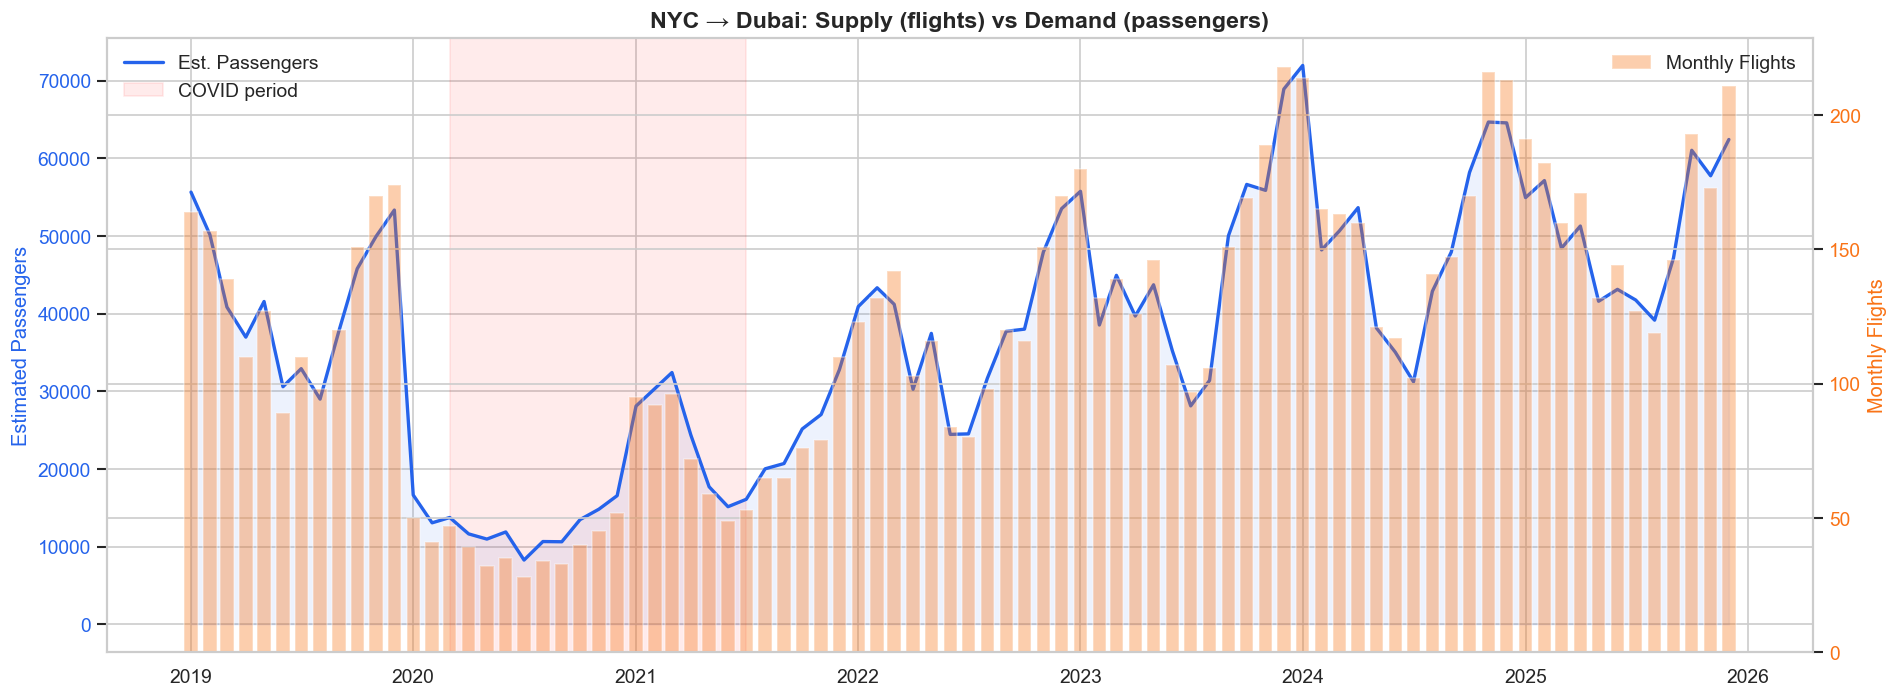

In [10]:
fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

# Passengers (left axis)
ax1.plot(merged["date"], merged["EST_PASSENGERS"], color="#2563eb",
         linewidth=2, label="Est. Passengers")
ax1.fill_between(merged["date"], merged["EST_PASSENGERS"], alpha=0.08, color="#2563eb")
ax1.set_ylabel("Estimated Passengers", color="#2563eb", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#2563eb")

# Flights (right axis)
ax2.bar(merged["date"], merged["MONTHLY_FLIGHTS"], width=22,
        alpha=0.35, color="#f97316", label="Monthly Flights")
ax2.set_ylabel("Monthly Flights", color="#f97316", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#f97316")

# COVID shading
ax1.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"),
            alpha=0.08, color="red", label="COVID period")

ax1.set_title("NYC → Dubai: Supply (flights) vs Demand (passengers)", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "m01_supply_demand_overview.png", dpi=150, bbox_inches="tight")
plt.show()


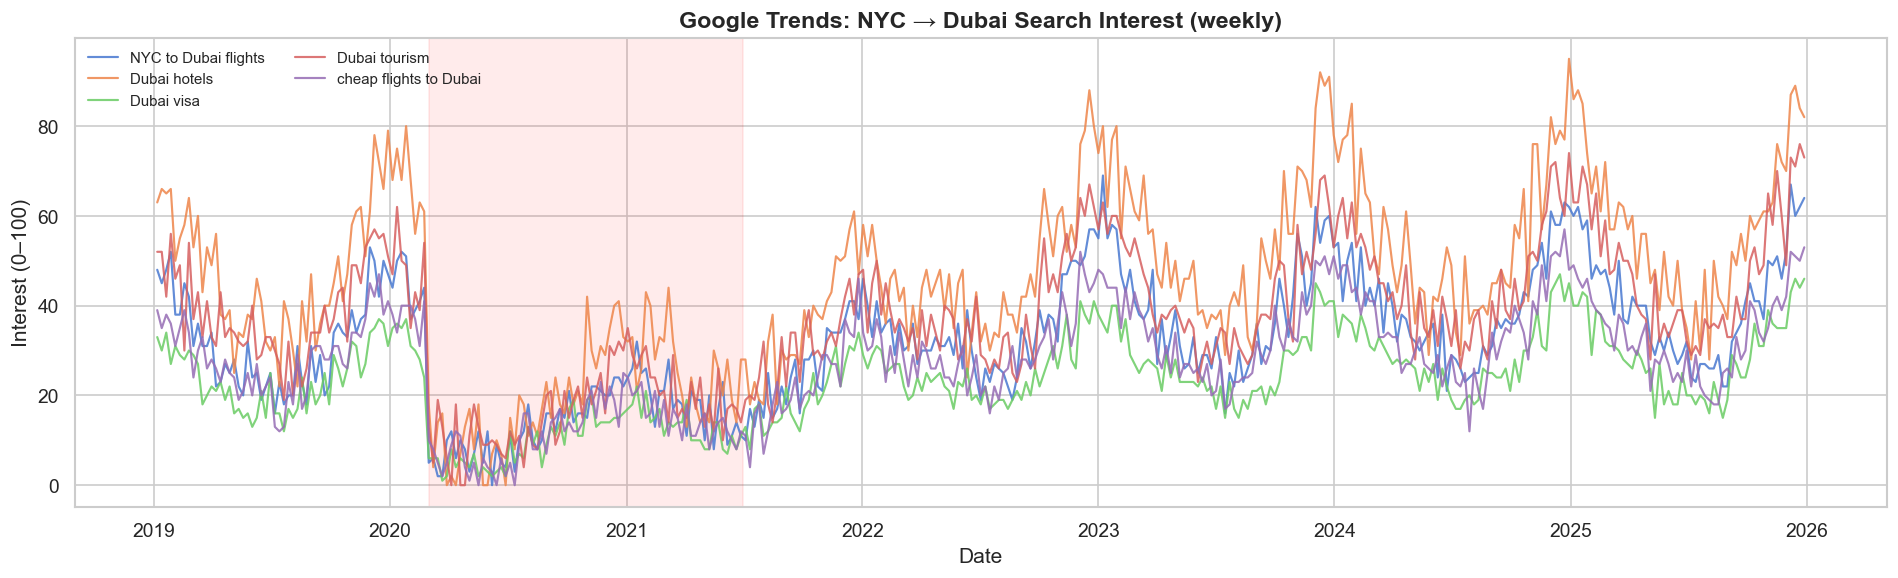

In [11]:
fig, ax = plt.subplots(figsize=(16, 5))

# All keywords over time
for i, col in enumerate(trends_raw.columns):
    ax.plot(trends_raw.index, trends_raw[col], linewidth=1.3, alpha=0.85, label=col)

ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"),
           alpha=0.08, color="red")
ax.set_title("Google Trends: NYC → Dubai Search Interest (weekly)", fontsize=14, fontweight="bold")
ax.set_ylabel("Interest (0–100)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "m01_trends_all_keywords.png", dpi=150, bbox_inches="tight")
plt.show()


### Seasonal Patterns


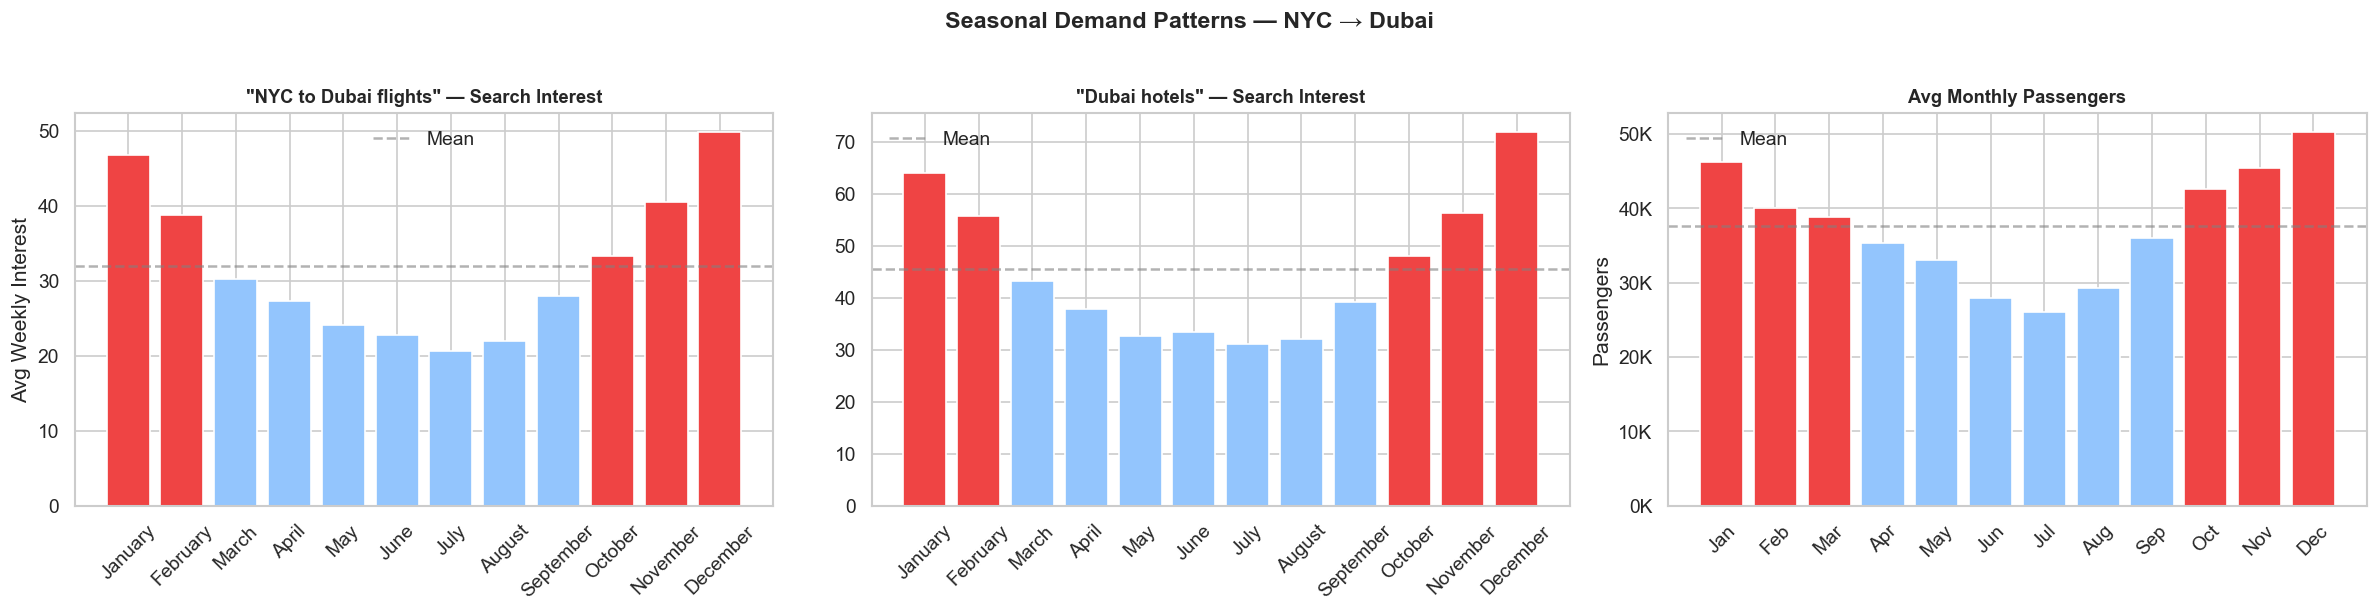

Peak months (above mean): January, February, October, November, December
Trough months: March, April, May, June, July, August, September


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: Search seasonality — "NYC to Dubai flights"
seasonal = extract_seasonal_patterns(trends_raw, "NYC to Dubai flights")
bar_colors = ["#ef4444" if p else "#93c5fd" for p in seasonal["IS_PEAK"]]
axes[0].bar(seasonal["MONTH_NAME"], seasonal["AVG_INTEREST"], color=bar_colors, edgecolor="white")
axes[0].axhline(seasonal["AVG_INTEREST"].mean(), color="gray", ls="--", alpha=0.6, label="Mean")
axes[0].set_title('"NYC to Dubai flights" — Search Interest', fontsize=11, fontweight="bold")
axes[0].set_ylabel("Avg Weekly Interest")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# Panel 2: Search seasonality — "Dubai hotels"
seasonal2 = extract_seasonal_patterns(trends_raw, "Dubai hotels")
bar_colors2 = ["#ef4444" if p else "#93c5fd" for p in seasonal2["IS_PEAK"]]
axes[1].bar(seasonal2["MONTH_NAME"], seasonal2["AVG_INTEREST"], color=bar_colors2, edgecolor="white")
axes[1].axhline(seasonal2["AVG_INTEREST"].mean(), color="gray", ls="--", alpha=0.6, label="Mean")
axes[1].set_title('"Dubai hotels" — Search Interest', fontsize=11, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

# Panel 3: Monthly passenger volume
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_means = merged.groupby(merged["date"].dt.month)["EST_PASSENGERS"].mean()
pax_colors = ["#ef4444" if month_means[m] > month_means.mean() else "#93c5fd" for m in range(1, 13)]
axes[2].bar(month_names, [month_means[m] for m in range(1, 13)], color=pax_colors, edgecolor="white")
axes[2].axhline(month_means.mean(), color="gray", ls="--", alpha=0.6, label="Mean")
axes[2].set_title("Avg Monthly Passengers", fontsize=11, fontweight="bold")
axes[2].set_ylabel("Passengers")
axes[2].tick_params(axis="x", rotation=45)
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
axes[2].legend()

plt.suptitle("Seasonal Demand Patterns — NYC → Dubai", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m01_seasonal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

print("Peak months (above mean):", ", ".join(seasonal[seasonal["IS_PEAK"]]["MONTH_NAME"].tolist()))
print("Trough months:", ", ".join(seasonal[~seasonal["IS_PEAK"]]["MONTH_NAME"].tolist()))

### Spike Detection & COVID Impact


Found 45 spikes for 'NYC to Dubai flights'


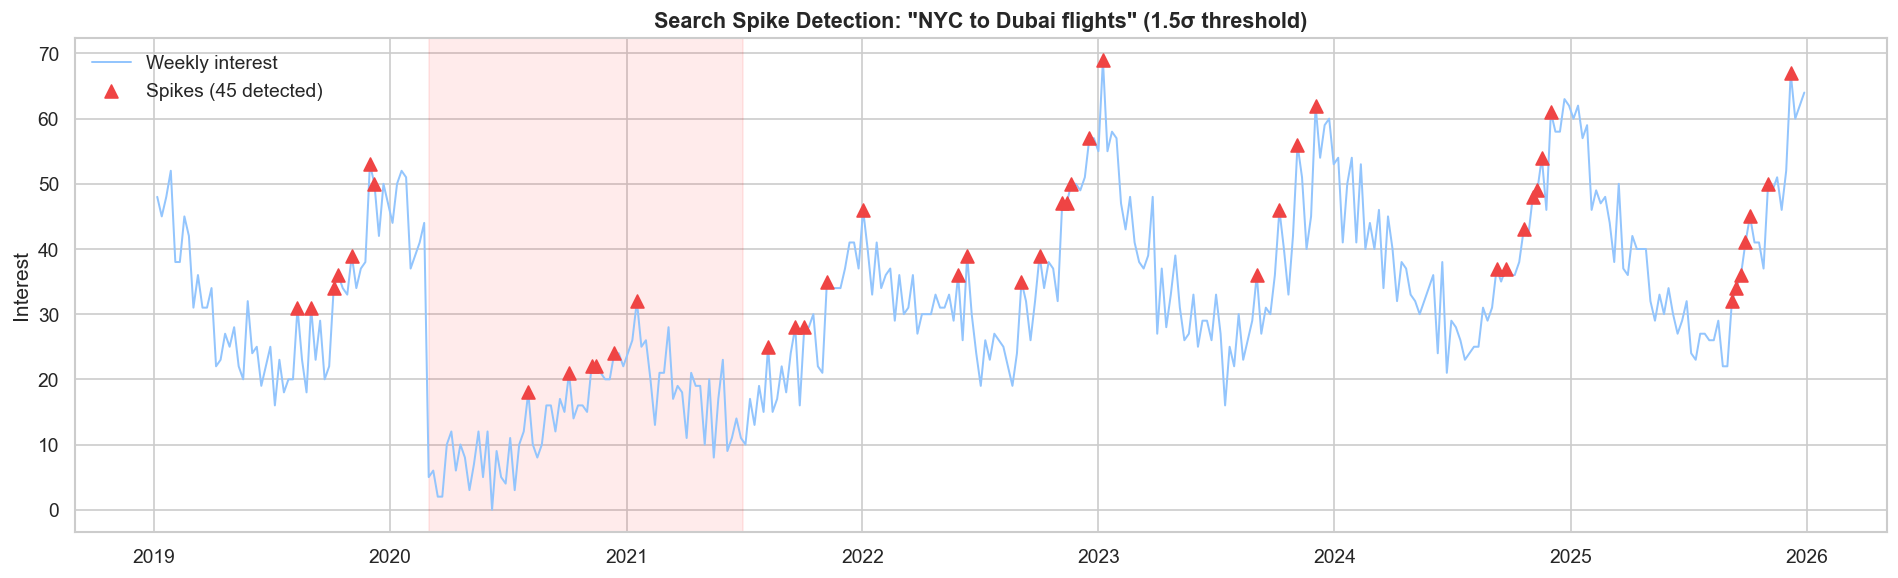


Top 5 spikes by magnitude:
  2020-08-02: 2.14x above rolling mean
  2021-08-08: 1.63x above rolling mean
  2023-11-05: 1.56x above rolling mean
  2019-12-01: 1.56x above rolling mean
  2023-10-08: 1.53x above rolling mean


In [13]:
target_kw = "NYC to Dubai flights"
spikes = detect_search_spikes(trends_raw, target_kw, threshold_std=1.5)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(trends_raw.index, trends_raw[target_kw], color="#93c5fd", linewidth=1.2, label="Weekly interest")
if not spikes.empty:
    ax.scatter(spikes.index, spikes[target_kw], color="#ef4444", s=60,
               zorder=5, marker="^", label=f"Spikes ({len(spikes)} detected)")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"),
           alpha=0.08, color="red")
ax.set_title(f'Search Spike Detection: "{target_kw}" (1.5σ threshold)', fontsize=13, fontweight="bold")
ax.set_ylabel("Interest")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m01_spike_detection.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTop 5 spikes by magnitude:")
for dt, row in spikes.nlargest(5, "SPIKE_MAGNITUDE").iterrows():
    print(f"  {dt.strftime('%Y-%m-%d')}: {row['SPIKE_MAGNITUDE']:.2f}x above rolling mean")

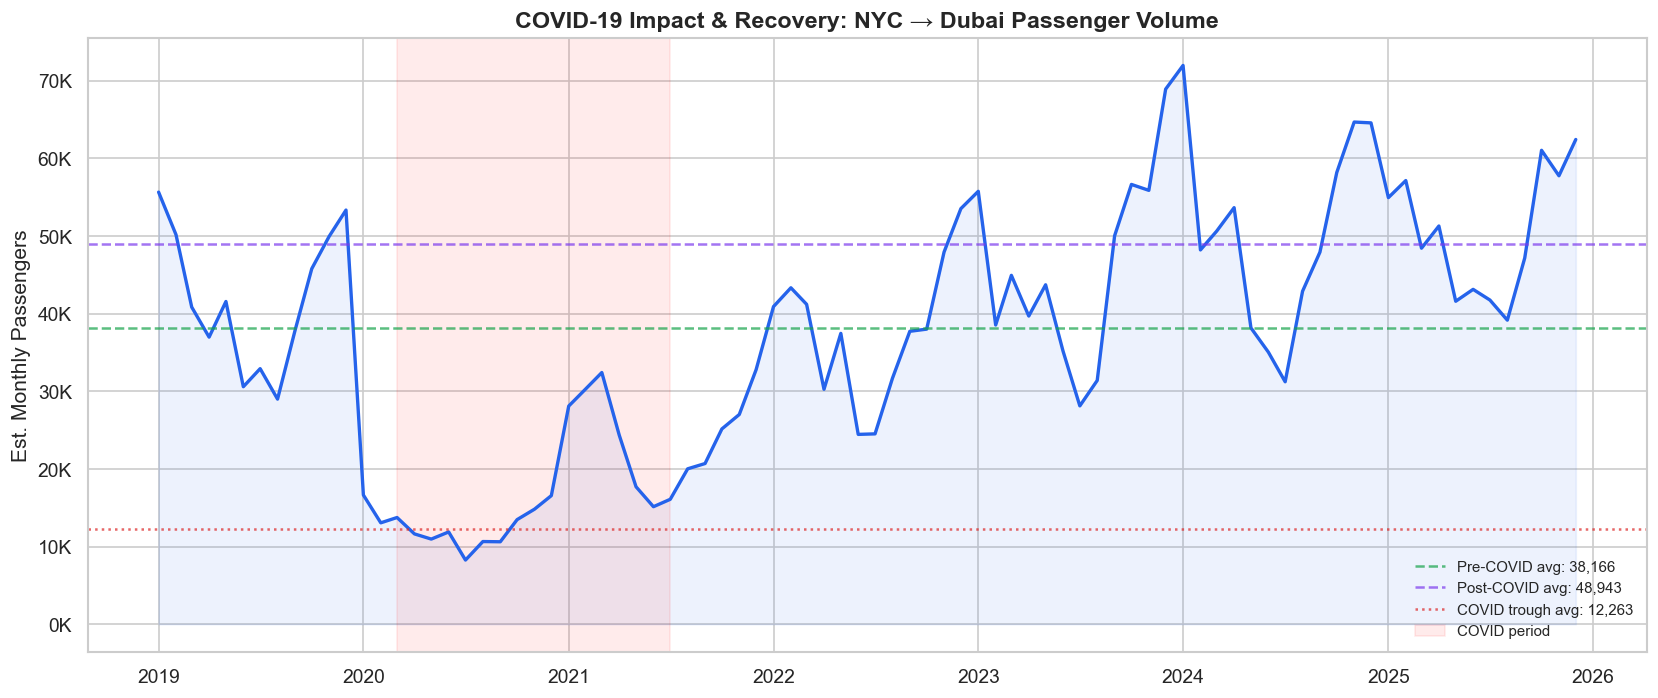

COVID drop: -67.9%
Post-COVID vs pre-COVID: +28.2%


In [14]:
pre_covid = merged[merged["date"] < "2020-03-01"]["EST_PASSENGERS"].mean()
covid_trough = merged[(merged["date"] >= "2020-03-01") &
                      (merged["date"] <= "2020-12-31")]["EST_PASSENGERS"].mean()
post_covid = merged[merged["date"] >= "2023-01-01"]["EST_PASSENGERS"].mean()

fig, ax = plt.subplots(figsize=(14, 6))

# Full time series
ax.plot(merged["date"], merged["EST_PASSENGERS"], color="#2563eb", linewidth=2)
ax.fill_between(merged["date"], merged["EST_PASSENGERS"], alpha=0.08, color="#2563eb")

# Reference lines
ax.axhline(pre_covid, color="#16a34a", ls="--", alpha=0.7, label=f"Pre-COVID avg: {pre_covid:,.0f}")
ax.axhline(post_covid, color="#7c3aed", ls="--", alpha=0.7, label=f"Post-COVID avg: {post_covid:,.0f}")
ax.axhline(covid_trough, color="#dc2626", ls=":", alpha=0.7, label=f"COVID trough avg: {covid_trough:,.0f}")

# COVID shading
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"),
           alpha=0.08, color="red", label="COVID period")

ax.set_title("COVID-19 Impact & Recovery: NYC → Dubai Passenger Volume", fontsize=14, fontweight="bold")
ax.set_ylabel("Est. Monthly Passengers")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.legend(loc="lower right", fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "m01_covid_impact.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"COVID drop: {((covid_trough - pre_covid)/pre_covid*100):.1f}%")
print(f"Post-COVID vs pre-COVID: {((post_covid - pre_covid)/pre_covid*100):+.1f}%")

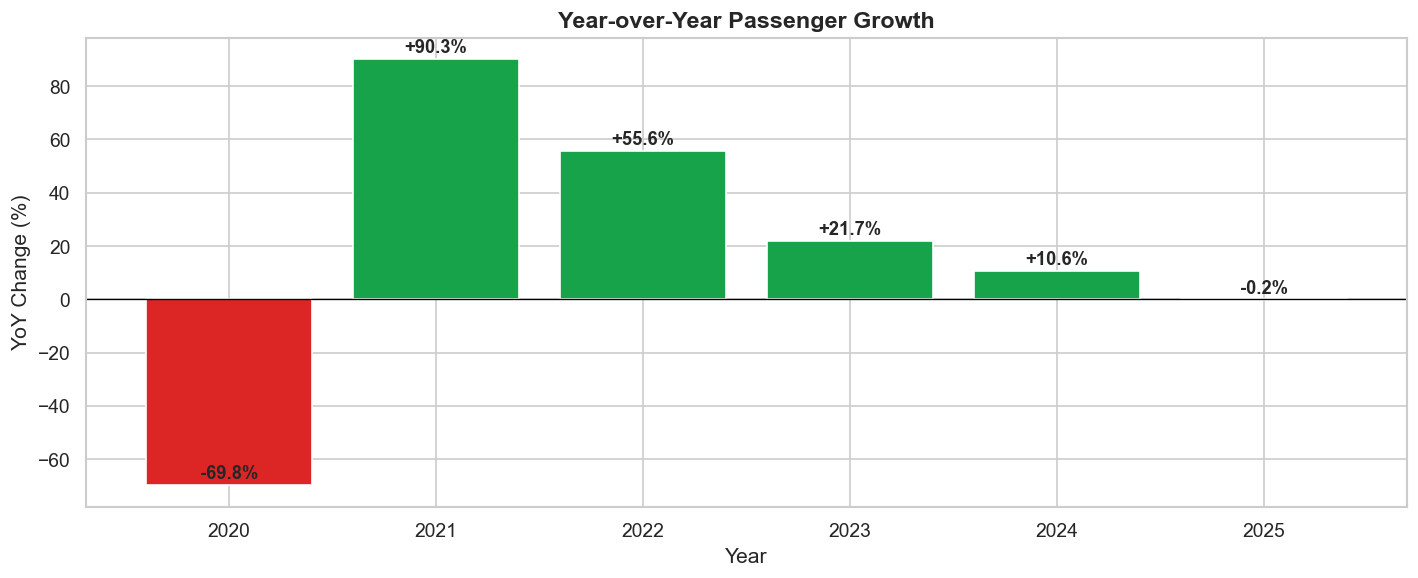

  2020: 152,334 pax (-69.8% vs 2019)
  2021: 289,859 pax (+90.3% vs 2020)
  2022: 451,026 pax (+55.6% vs 2021)
  2023: 548,861 pax (+21.7% vs 2022)
  2024: 607,193 pax (+10.6% vs 2023)
  2025: 605,877 pax (-0.2% vs 2024)


In [15]:
yearly = merged.groupby(merged["date"].dt.year)["EST_PASSENGERS"].sum()

fig, ax = plt.subplots(figsize=(12, 5))
yoy_pct = yearly.pct_change() * 100

colors = ["#16a34a" if v >= 0 else "#dc2626" for v in yoy_pct.dropna()]
bars = ax.bar(yoy_pct.dropna().index.astype(str), yoy_pct.dropna(), color=colors, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)

for bar, val in zip(bars, yoy_pct.dropna()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Year-over-Year Passenger Growth", fontsize=14, fontweight="bold")
ax.set_ylabel("YoY Change (%)")
ax.set_xlabel("Year")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m01_yoy_growth.png", dpi=150, bbox_inches="tight")
plt.show()

for year in sorted(yearly.index):
    if year > yearly.index.min():
        prev, curr = yearly[year-1], yearly[year]
        pct = (curr - prev) / prev * 100
        print(f"  {year}: {curr:,.0f} pax ({pct:+.1f}% vs {year-1})")


## Demand Forecasting — Prophet vs SARIMA


In [16]:
# ═══════════════════════════════════════════════════════════
# FORECASTING
# ═══════════════════════════════════════════════════════════

prophet_df = prepare_forecast_data(capacity_raw, trends_raw)
prophet_results = train_prophet_model(prophet_df, test_months=6, forecast_months=12)


Added 5 Trends regressors: ['trend_nyc_to_dubai_flights', 'trend_dubai_hotels', 'trend_dubai_visa', 'trend_dubai_tourism', 'trend_cheap_flights_to_dubai']
Forecast data: 84 months
Prophet — Train: 78 months, Test: 6 months
  Regressors: ['supply_flights', 'load_factor', 'trend_nyc_to_dubai_flights', 'trend_dubai_hotels', 'trend_dubai_visa', 'trend_dubai_tourism', 'trend_cheap_flights_to_dubai']


12:43:57 - cmdstanpy - INFO - Chain [1] start processing
12:43:58 - cmdstanpy - INFO - Chain [1] done processing



  MAE: 1,245  |  MAPE: 2.4%


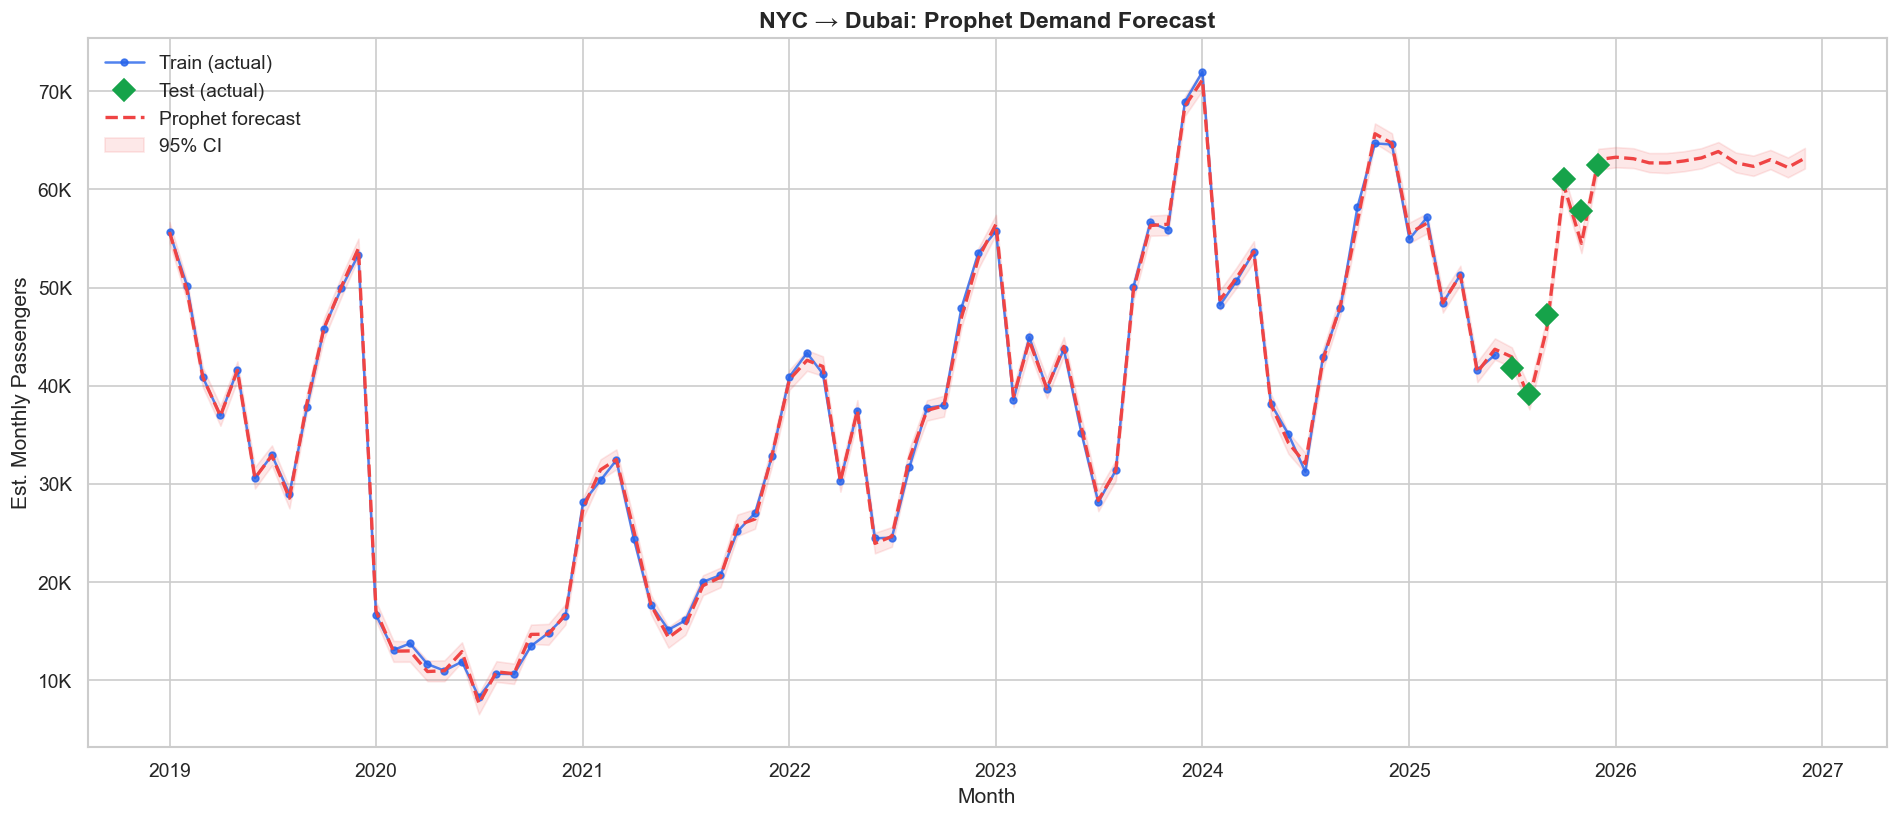

In [17]:
fc = prophet_results["forecast"]
tr = prophet_results["train"]
te = prophet_results["test"]

fig, ax = plt.subplots(figsize=(16, 7))

# Training data
ax.plot(tr["ds"], tr["y"], "o-", color="#2563eb", markersize=4, linewidth=1.5,
        label="Train (actual)", alpha=0.8)

# Test actuals
ax.plot(te["ds"], te["y"], "D", color="#16a34a", markersize=9,
        label="Test (actual)", zorder=5)

# Forecast line
ax.plot(fc["ds"], fc["yhat"], "--", color="#ef4444", linewidth=2, label="Prophet forecast")

# 95% confidence interval
ax.fill_between(fc["ds"], fc["yhat_lower"], fc["yhat_upper"],
                alpha=0.12, color="#ef4444", label="95% CI")

ax.set_title("NYC → Dubai: Prophet Demand Forecast", fontsize=14, fontweight="bold")
ax.set_ylabel("Est. Monthly Passengers")
ax.set_xlabel("Month")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "m01_prophet_forecast.png", dpi=150, bbox_inches="tight")
plt.show()


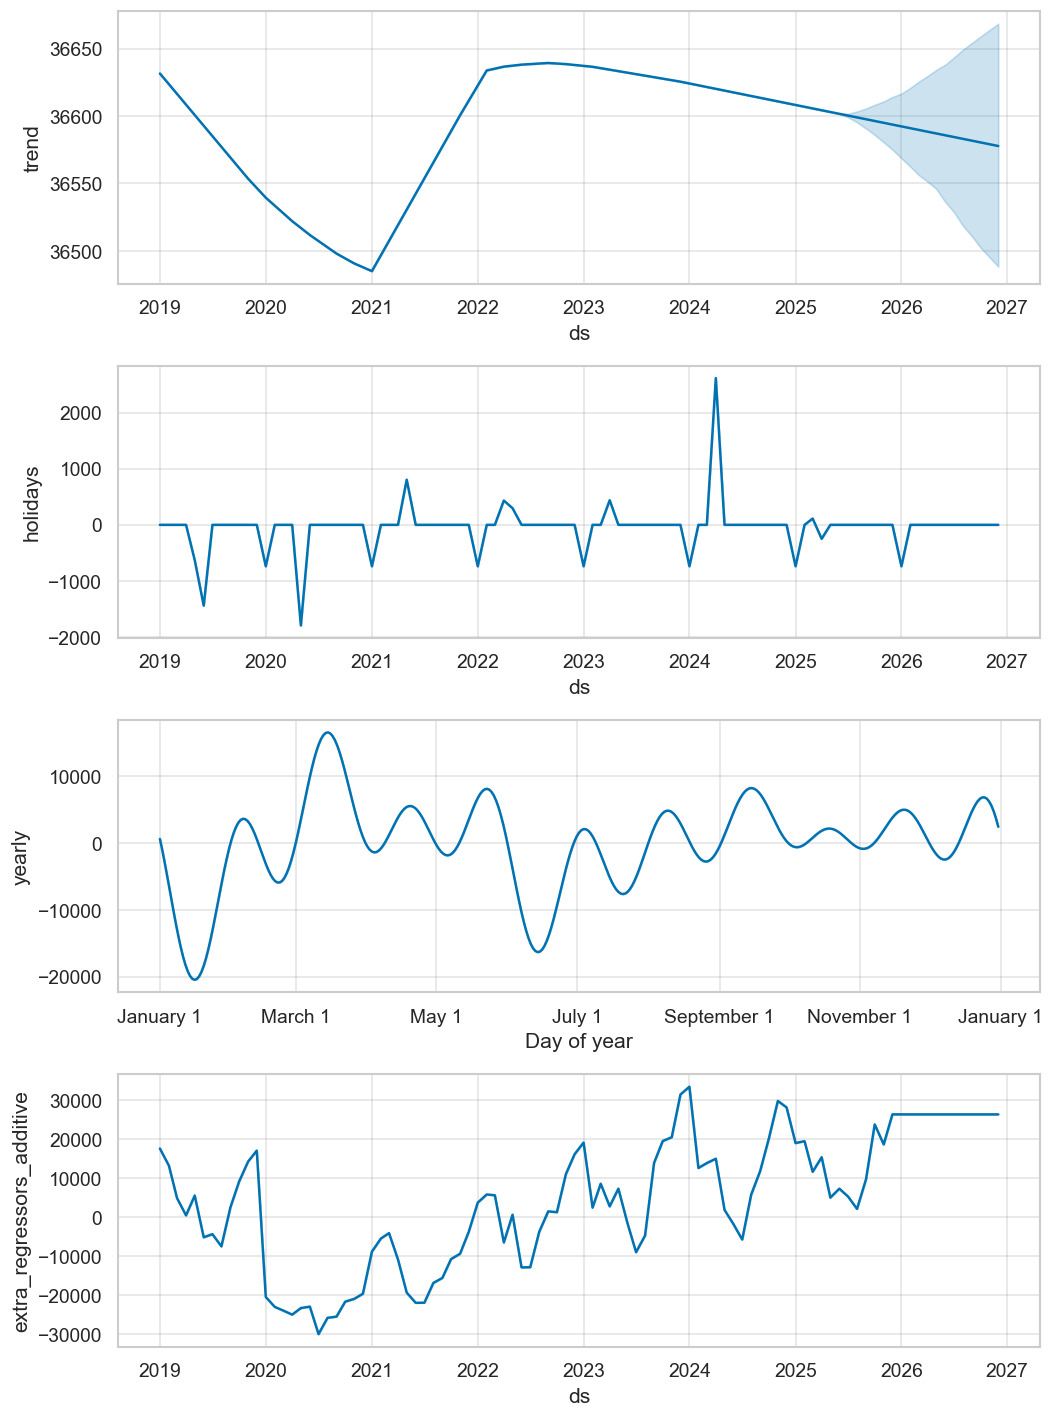

In [18]:
fig = prophet_results["model"].plot_components(prophet_results["forecast"])
plt.savefig(FIGURES_DIR / "m01_prophet_components.png", dpi=150, bbox_inches="tight")
plt.show()


In [19]:
sarima_results = train_sarima_model(prophet_df, test_months=6)
comparison = compare_models(prophet_results, sarima_results)
display(comparison)

SARIMA(1, 1, 1)x(1, 1, 1, 12) — Train: 78, Test: 6
  MAE: 4,865  |  MAPE: 9.9%  |  AIC: 1065

Winner: Prophet
                          Model         MAE    MAPE%         AIC
Prophet (holidays + regressors) 1244.648680 2.411963         NaN
              SARIMA (baseline) 4865.408229 9.913814 1064.761067


,Model,MAE,MAPE%,AIC
0,Prophet (holidays + regressors),1244.648680,2.411963,NaN
1,SARIMA (baseline),4865.408229,9.913814,1064.761067


## Search → Demand Lag Analysis

*If someone searches "NYC to Dubai flights" today, how many months until they actually fly?*


Best lag: 0 month(s) (r=0.8288, p=0.0)


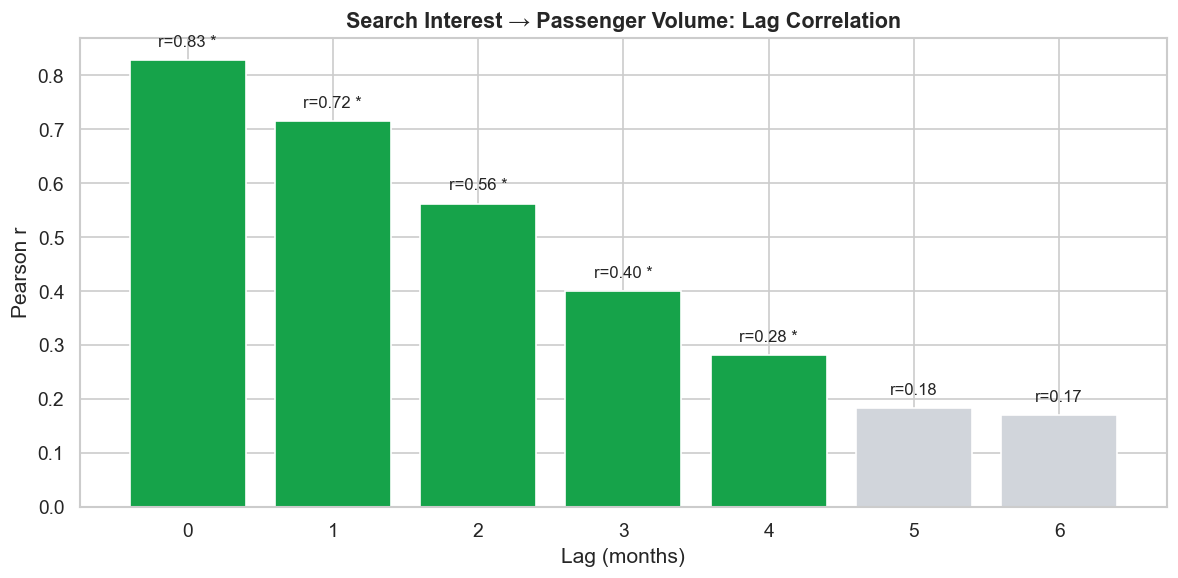

,lag_months,description,correlation,p_value,significant,n
0,0,Same month,0.8288,0.0000,True,84
1,1,Search leads by 1 month(s),0.7152,0.0000,True,83
2,2,Search leads by 2 month(s),0.5621,0.0000,True,82
3,3,Search leads by 3 month(s),0.4004,0.0002,True,81
4,4,Search leads by 4 month(s),0.2809,0.0116,True,80
5,5,Search leads by 5 month(s),0.1829,0.1067,False,79
6,6,Search leads by 6 month(s),0.1690,0.1390,False,78


In [20]:
trend_cols = [c for c in prophet_df.columns if c.startswith("trend_")]
lag_results = analyze_search_demand_lag(prophet_df, search_col=trend_cols[0])

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#16a34a" if s else "#d1d5db" for s in lag_results["significant"]]
bars = ax.bar(lag_results["lag_months"], lag_results["correlation"], color=colors, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.5)

for bar, row in zip(bars, lag_results.itertuples()):
    label = f"r={row.correlation:.2f}"
    if row.significant:
        label += " *"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            label, ha="center", va="bottom", fontsize=10)

ax.set_title("Search Interest → Passenger Volume: Lag Correlation",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Lag (months)")
ax.set_ylabel("Pearson r")
ax.set_xticks(lag_results["lag_months"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "m01_lag_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

display(lag_results)


In [21]:
recs = generate_push_timing(prophet_results["forecast"], lead_months=3)
if not recs.empty:
    print("Push Timing Recommendations:\n")
    for _, r in recs.iterrows():
        print(f"  {r['RECOMMENDATION']}")
    print()
    display(recs[["PEAK_MONTH", "FORECAST_PAX", "PUSH_START", "PUSH_END", "SEASON"]])
else:
    print("No peak months in forecast horizon")


Push Timing Recommendations:

  Push inventory Mar 2026-May 2026 -> peak Jun 2026 (63,200 est. passengers). Summer Low.
  Push inventory Apr 2026-Jun 2026 -> peak Jul 2026 (63,857 est. passengers). Summer Low.



,PEAK_MONTH,FORECAST_PAX,PUSH_START,PUSH_END,SEASON
0,2026-06-01,63200.047581,2026-03-01,2026-05-01,Summer Low
1,2026-07-01,63856.872639,2026-04-01,2026-06-01,Summer Low


In [ ]:
# ═══════════════════════════════════════════════════════════
# SAVE OUTPUTS
# ═══════════════════════════════════════════════════════════
out = DATA_PROCESSED / "demand_forecasting"
out.mkdir(parents=True, exist_ok=True)

capacity_raw.to_csv(out / "monthly_capacity.csv", index=False)
merged.to_csv(out / "merged_supply_demand.csv", index=False)
prophet_results["forecast"].to_csv(out / "prophet_forecast.csv", index=False)
lag_results.to_csv(out / "lag_analysis.csv", index=False)
if not recs.empty:
    recs.to_csv(out / "push_timing_recommendations.csv", index=False)
save_trends_data(trends_raw)

print(f"Outputs saved to: {out}")
print(f"Figures saved to: {FIGURES_DIR}")


Saved -> C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\raw\google_trends\google_trends_nyc_dubai.csv
Outputs saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\demand_forecasting
Figures saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures


## Executive Summary — M01 Demand Forecasting

### Key Findings

| # | Finding | Value | OTA Implication |
|---|---------|-------|-----------------|
| 1 | **Peak months** | Oct–Feb (Dec highest) | Concentrate 60% of Dubai ad spend in Sept–Feb |
| 2 | **Trough months** | Jun–Aug (Jul lowest) | Reduce spend OR test discount bundles |
| 3 | **COVID impact** | -67.9% drop, +28.2% recovery | Route is stronger than pre-pandemic; safe to forecast growth |
| 4 | **Prophet MAPE** | 2.4% (vs SARIMA 9.9%) | Use Prophet + Trends regressors for production forecasting |
| 5 | **Search lead time** | 1–2 months (r=0.72/0.56) | Google Trends is a 60-day early warning system |
| 6 | **YoY growth** | +10.6% (2024), plateauing | Shift from growth-capture to market-share strategy |

### Recommended Actions
1. **Automated Trends monitoring** — when "NYC to Dubai flights" exceeds 1.5σ, trigger ad-spend increase
2. **Seasonal budget allocation** — 60% of annual Dubai marketing in Sept–Feb window
3. **Ramadan pause** — reduce spend during Ramadan quarter, reallocate to post-Ramadan "catch-up" push
4. **Prophet pipeline** — deploy monthly retraining with latest Trends + capacity data
5. **Push timing** — begin inventory pushes 3 months before predicted peak months
